## OPSKF: 1-D Free-Fall 

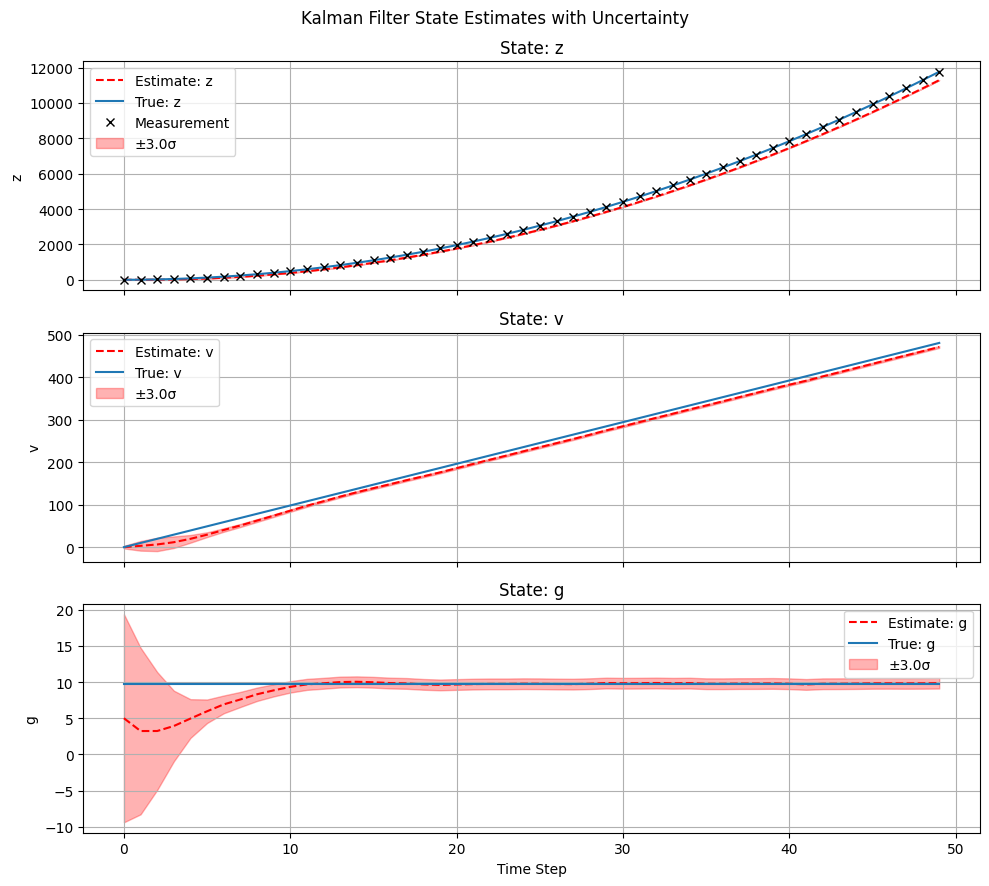

In [ ]:
dt = 1.0

# State-transition
F = np.array([
    [1.0, dt, 0.5*dt**2],
    [0.0, 1.0,       dt],
    [0.0, 0.0,      1.0]
])

# Measurement: position only
H = lambda x,u: np.array([[1.0, 0.0, 0.0]])
h = lambda x,u: np.array([x[0]])

# Noise covariances
Q = np.diag([0.1, 0.1, 0.01])
R = np.array([[1.0]])

# Simulate “true” motion with g = 9.8
N = 50
g_true = 9.8
x_true = np.zeros((N,3))
x_true[0] = [0.0, 0.0, g_true]
for k in range(1, N):
    x_true[k] = F @ x_true[k-1]

# Noisy position measurements
y = x_true[:,0] + np.random.randn(N)*np.sqrt(R[0,0])
y_df = pd.DataFrame(y, columns=['z'])

# Initial guess (biased gravity)
g_est0 = 5.0
x0 = pd.Series([0.0, 0.0, g_est0], index=['z','v','g'])
P0 = np.diag([1.0, 1.0, (g_est0 - g_true)**2])

# Instantiate OPSKF (observability-informed)
opskf = pk.OPSKF(
    f=lambda x,u: F@x,
    h=h,
    Q=Q, R=R,
    dt=dt,
    system_type=pk.SystemType.DISCRETE_TIME_INVARIANT,
    method='nullspace',    # or 'stochastic'
    tol_null=1e-1           # null‐space tolerance
)

# Run the filter
x_est_ops, P_est_ops = opskf.run(x0, P0, y_df, F, H)
x_est_ops = x_est_ops.iloc[:N]
P_est_ops = P_est_ops[:N]


opskf.plot_kf_predictions(
    x_est_ops, P_est_ops,
    x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),
    y_df=y_df
)

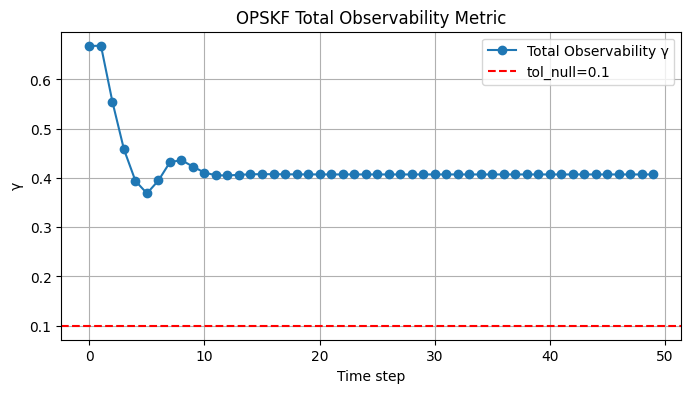

In [ ]:
opskf.plot_observability("total")

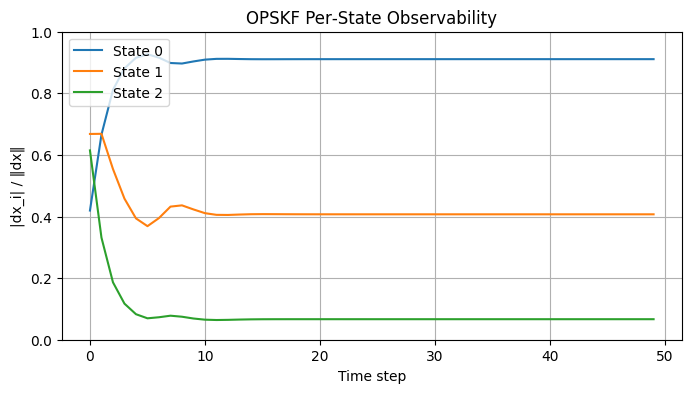

In [ ]:
opskf.plot_observability("individual")